<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/DL_Day6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from tensorflow.keras.datasets import mnist

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Conv2D
from tensorflow.keras.layers import Flatten,MaxPooling2D

In [51]:
(X_train , y_train) , (X_test ,y_test) = mnist.load_data()

In [52]:
X_train = X_train/255
X_test = X_test/255

In [53]:
X_train.reshape(-1,28,28,1)
X_test.reshape(-1,28,28,1)

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [54]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3) , activation= 'relu' , input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128 , activation = 'relu'))
model.add(Dense(10 , activation= 'softmax'))

In [55]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy' , metrics=['accuracy'])

In [57]:
history = model.fit(X_train , y_train ,epochs = 5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9485 - loss: 0.1739 - val_accuracy: 0.9784 - val_loss: 0.0766
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9819 - loss: 0.0588 - val_accuracy: 0.9826 - val_loss: 0.0589
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9889 - loss: 0.0366 - val_accuracy: 0.9859 - val_loss: 0.0482
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.9923 - loss: 0.0243 - val_accuracy: 0.9844 - val_loss: 0.0540
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 0.9835 - val_loss: 0.0638


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
evaluate = model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9855 - loss: 0.0505


In [60]:
evaluate

[0.05045795813202858, 0.9854999780654907]

In [61]:
predict = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [62]:
prediction_class = predict.argmax(axis = 1)

In [63]:
prediction_class

array([7, 2, 1, ..., 4, 5, 6])

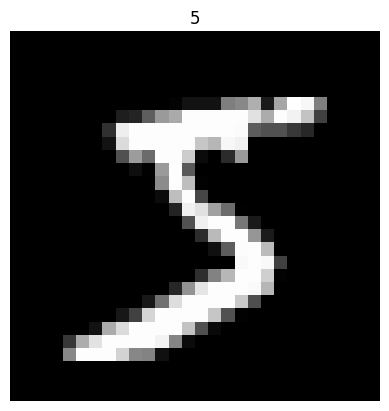

In [64]:
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title(y_train[0])
plt.axis('off')
plt.show()

Build cnn with
conv2D , Maxpooling2D , Flatten , Dense , Softmax

In [65]:
(X_train , y_train) , (X_test , y_test) = mnist.load_data()

In [66]:
X_train = X_train/255
X_test = X_test/255
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [67]:
from tensorflow.keras.layers import LeakyReLU
cnn_model = Sequential()
cnn_model.add(Conv2D(32 , (3,3),activation = 'relu',input_shape = (28,28,1)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128 ))
cnn_model.add(LeakyReLU(alpha = 0.01))
cnn_model.add(Dense(10 , activation = 'softmax'))

In [68]:
cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [69]:
cnn_model.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])
history = cnn_model.fit(X_train,y_train , epochs = 5, validation_split=0.2 , validation_data= (X_test , y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9556 - loss: 0.1475 - val_accuracy: 0.9797 - val_loss: 0.0616
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9848 - loss: 0.0500 - val_accuracy: 0.9816 - val_loss: 0.0515
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9908 - loss: 0.0303 - val_accuracy: 0.9856 - val_loss: 0.0431
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9877 - val_loss: 0.0406
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9876 - val_loss: 0.0425


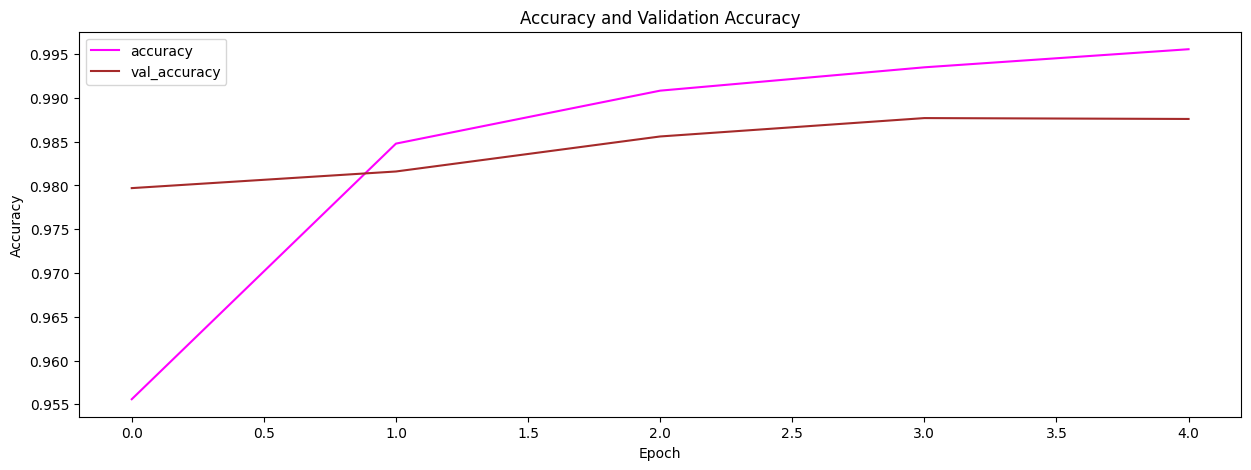

In [70]:
plt.figure(figsize=(15,5))
plt.plot(history.history['accuracy'],label = 'accuracy' , color = 'magenta')
plt.plot(history.history['val_accuracy'] , label = 'val_accuracy' , color = 'brown')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy and Validation Accuracy')
plt.legend()
plt.show()

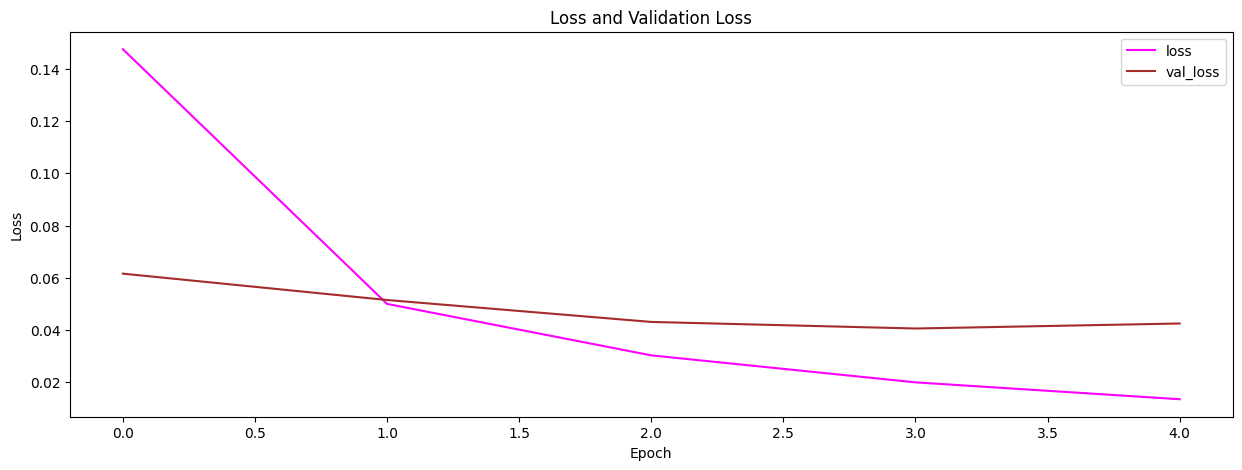

In [71]:
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'],label = 'loss' , color = 'magenta')
plt.plot(history.history['val_loss'] , label = 'val_loss' , color = 'brown')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss and Validation Loss')
plt.legend()
plt.show()

In [72]:
cnn_model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9876 - loss: 0.0425


[0.042487092316150665, 0.9876000285148621]

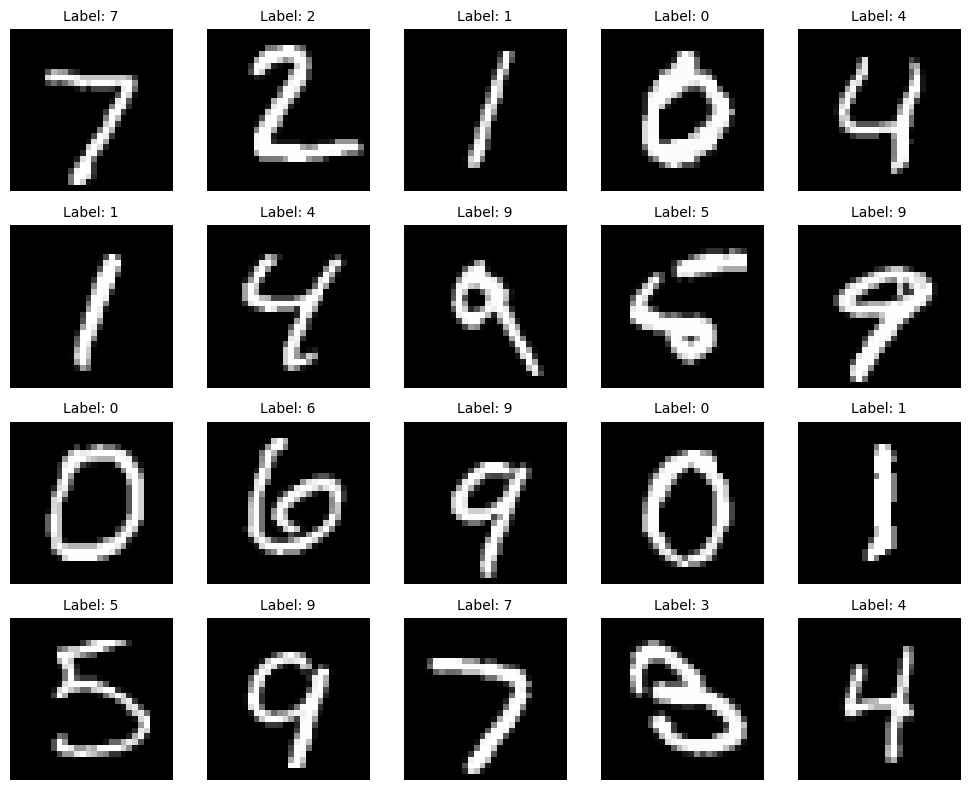

In [73]:
plt.figure(figsize=(10, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_test[i]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()